In [1]:
!pip install pytorch-tabnet
!pip install pytorch-tabular

## Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabular import TabularModel
from pytorch_tabular.models import TabTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
from copy import deepcopy
import pickle

## Utils

In [3]:
def get_data_root():
  '''
    Ritorna il percorso della cartella contenente i dati in base all'ambiente di esecuzione.
  '''
  try:
      import google.colab
      from google.colab import drive

      try:
          drive.mount("/content/drive", force_remount=True)
          return "/content/drive/MyDrive/ColabContent/Data_analytics"
      except Exception:
          print("Drive non montabile")
          return "/content"

  except ImportError:
      return "../../data"

get_data_root()

Mounted at /content/drive


'/content/drive/MyDrive/ColabContent/Data_analytics'

In [10]:
def load_assets(path):
  with open(path, 'rb') as f:
        return pickle.load(f)

## Global variables

In [ ]:
DATA_ROOT = get_data_root()
DATASET_PATH = f"{DATA_ROOT}/Dataset2526/train.csv"

TRAIN_SET_PATH = f"{DATA_ROOT}/train_processed.csv"
VAL_SET_PATH = f"{DATA_ROOT}/val_processed.csv"
TEST_SET_PATH = f"{DATA_ROOT}/test_processed.csv"

TRAIN_SET_PATH_ONLY_LABEL = f"{DATA_ROOT}/train_processed_only_label.csv"
VAL_SET_PATH_ONLY_LABEL = f"{DATA_ROOT}/val_processed_only_label.csv"
TEST_SET_PATH_ONLY_LABEL = f"{DATA_ROOT}/test_processed_only_label.csv"

ASSETS_PATH = f"preprocessing_assets.pkl"
ASSETS_PATH_ONLY_LABEL = f"preprocessing_assets_only_label.pkl"
SEED = 42

Mounted at /content/drive


## Seed per riproducibilità

In [5]:
def fix_random(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

## Impostazione GPU

In [6]:
# look for GPU
if torch.backends.mps.is_available():
    print("MPS device is available.")
    device = torch.device("mps")
elif torch.cuda.is_available():
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.")
    device = torch.device("cpu")

No GPU acceleration available.


# Modeling (tabular)

## 1. TabNet

In [22]:
train = pd.read_csv(TRAIN_SET_PATH)
val = pd.read_csv(VAL_SET_PATH)
test = pd.read_csv(TEST_SET_PATH)

X_train = train.drop(columns=['grade'])
y_train = train["grade"]

X_val = val.drop(columns=['grade'])
y_val = val["grade"]

X_test = test.drop(columns=['grade'])
y_test = test["grade"]

print(f"TRAIN:\nX: {X_train.shape}\ny: {y_train.shape}")
print(f"VAL:\nX: {X_val.shape}\ny: {y_val.shape}")
print(f"TEST:\nX: {X_test.shape}\ny: {y_test.shape}")

TRAIN:
X: (33747, 38)
y: (33747,)
VAL:
X: (14830, 38)
y: (14830,)
TEST:
X: (14831, 38)
y: (14831,)


### Iperparametri

In [23]:
param_list = {
    'n_d': [16, 32],
    'n_a': [16, 32],
    'n_steps': [3, 5],
    'gamma': [1.3, 1.5],
    'lambda_sparse': [1e-3, 1e-2],
    'mask_type': ['entmax']
}


### Random search

In [ ]:
def sample_params(params_list):
  '''
  Estrae un combinazione di parametri casuali
  '''
  params = {k: random.choice(v) for k, v in params_list.items()}
  params['n_a'] = params['n_d']
  return params


best_score = -1
best_params = None

N_TRIALS = 10

for trial in range(N_TRIALS):
    params = sample_params(param_list)
    print(f"\nTrial {trial+1}/{N_TRIALS} | Params: {params}")

    # Configurazione modello
    model = TabNetClassifier(
        **params,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size": 20, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        verbose=1
    )

    # Train
    model.fit(
        X_train.values, y_train.values,
        eval_set=[(X_val.values, y_val.values)],
        eval_metric=['accuracy'],
        max_epochs=100,
        patience=10,
        batch_size=1024,
        virtual_batch_size=128,
        drop_last=False
    )

    # Risultati
    score = model.best_cost
    print("Val score:", score)

    if score > best_score:
        best_score = score
        best_params = params
        best_model = deepcopy(model)

best_model.save_model(f"../Test_module/models/tabnet")

print(f"Miglior score: {best_score}")
print(f"Migliori parametri: {best_params}")




Trial 1/10 | Params: {'n_d': 16, 'n_a': 16, 'n_steps': 5, 'gamma': 1.3, 'lambda_sparse': 0.001, 'mask_type': 'entmax'}


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.67273 | val_0_accuracy: 0.25792 |  0:00:06s
epoch 1  | loss: 0.74311 | val_0_accuracy: 0.20229 |  0:00:13s
epoch 2  | loss: 0.64229 | val_0_accuracy: 0.25597 |  0:00:15s
epoch 3  | loss: 0.61591 | val_0_accuracy: 0.13682 |  0:00:17s
epoch 4  | loss: 0.59334 | val_0_accuracy: 0.17519 |  0:00:19s
epoch 5  | loss: 0.55356 | val_0_accuracy: 0.20782 |  0:00:22s
epoch 6  | loss: 0.53735 | val_0_accuracy: 0.08645 |  0:00:25s
epoch 7  | loss: 0.51385 | val_0_accuracy: 0.135   |  0:00:27s
epoch 8  | loss: 0.49986 | val_0_accuracy: 0.22468 |  0:00:29s
epoch 9  | loss: 0.48874 | val_0_accuracy: 0.2561  |  0:00:31s
epoch 10 | loss: 0.47283 | val_0_accuracy: 0.21976 |  0:00:33s

Early stopping occurred at epoch 10 with best_epoch = 0 and best_val_0_accuracy = 0.25792


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Val score: 0.2579231287929872

Trial 2/10 | Params: {'n_d': 16, 'n_a': 16, 'n_steps': 5, 'gamma': 1.3, 'lambda_sparse': 0.001, 'mask_type': 'entmax'}


...

Val score: 0.9078219824679703

Trial 10/10 | Params: {'n_d': 16, 'n_a': 16, 'n_steps': 5, 'gamma': 1.3, 'lambda_sparse': 0.01, 'mask_type': 'entmax'}


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.7393  | val_0_accuracy: 0.08449 |  0:00:02s
epoch 1  | loss: 0.79081 | val_0_accuracy: 0.06669 |  0:00:04s
epoch 2  | loss: 0.67006 | val_0_accuracy: 0.0617  |  0:00:07s
epoch 3  | loss: 0.62605 | val_0_accuracy: 0.11126 |  0:00:09s
epoch 4  | loss: 0.59924 | val_0_accuracy: 0.15644 |  0:00:11s
epoch 5  | loss: 0.5467  | val_0_accuracy: 0.26453 |  0:00:14s
epoch 6  | loss: 0.54697 | val_0_accuracy: 0.15752 |  0:00:16s
epoch 7  | loss: 0.51063 | val_0_accuracy: 0.14902 |  0:00:19s
epoch 8  | loss: 0.51262 | val_0_accuracy: 0.1528  |  0:00:21s
epoch 9  | loss: 0.50854 | val_0_accuracy: 0.16905 |  0:00:24s
epoch 10 | loss: 0.4812  | val_0_accuracy: 0.1737  |  0:00:26s
epoch 11 | loss: 0.49236 | val_0_accuracy: 0.3205  |  0:00:28s
epoch 12 | loss: 0.48845 | val_0_accuracy: 0.3791  |  0:00:30s
epoch 13 | loss: 0.47774 | val_0_accuracy: 0.57094 |  0:00:33s
epoch 14 | loss: 0.4641  | val_0_accuracy: 0.23837 |  0:00:36s
epoch 15 | loss: 0.47744 | val_0_accuracy: 0.51052 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Val score: 0.9066082265677681
Successfully saved model at /content/drive/MyDrive/ColabContent/Data_analytics/models/tabnet.zip
Miglior score: 0.9132164531355361
Migliori parametri: {'n_d': 32, 'n_a': 32, 'n_steps': 3, 'gamma': 1.3, 'lambda_sparse': 0.01, 'mask_type': 'entmax'}


### Valutazione

In [ ]:
tabnet_model = TabNetClassifier()
tabnet_model.load_model(f"../Test_module/models/tabnet.zip")

y_pred = tabnet_model.predict(X_test.values)
print(f"Test accuracy finale: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Test accuracy finale: 0.9177398691929067
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2647
           1       0.95      0.92      0.93      3789
           2       0.93      0.94      0.93      3689
           3       0.93      0.92      0.92      2156
           4       0.89      0.88      0.88      1203
           5       0.78      0.69      0.73       711
           6       0.75      0.86      0.80       636

    accuracy                           0.92     14831
   macro avg       0.88      0.88      0.88     14831
weighted avg       0.92      0.92      0.92     14831



### Visualizzazione

{'loss': 0.36142008196308967, 'lr': 0.014580000000000003, 'val_0_accuracy': 0.8884018880647336}


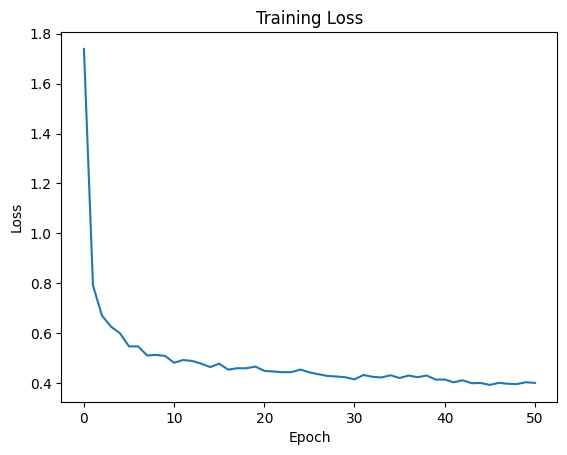

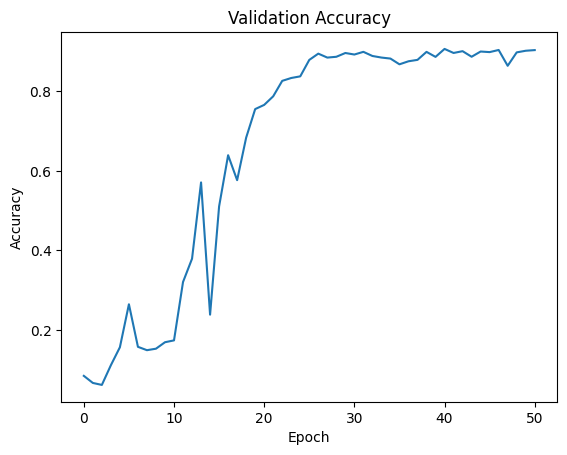

In [26]:
history = best_model.history

print(best_model.history.epoch_metrics)

plt.figure()
plt.plot(model.history["loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure()
plt.plot(model.history["val_0_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.show()



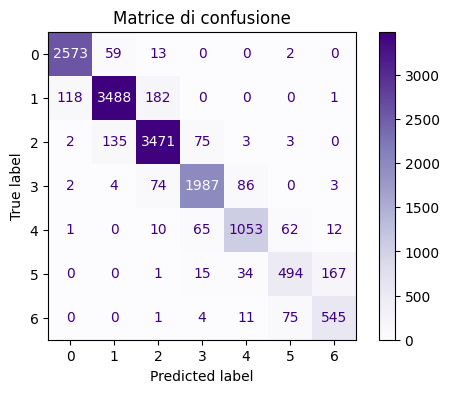

In [27]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(7))
disp.plot(cmap='Purples', ax=ax)
plt.title("Matrice di confusione")
plt.show()

### Feature importance

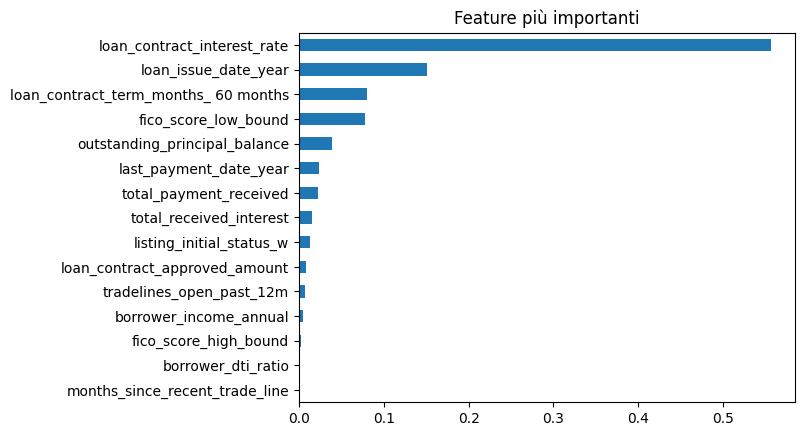

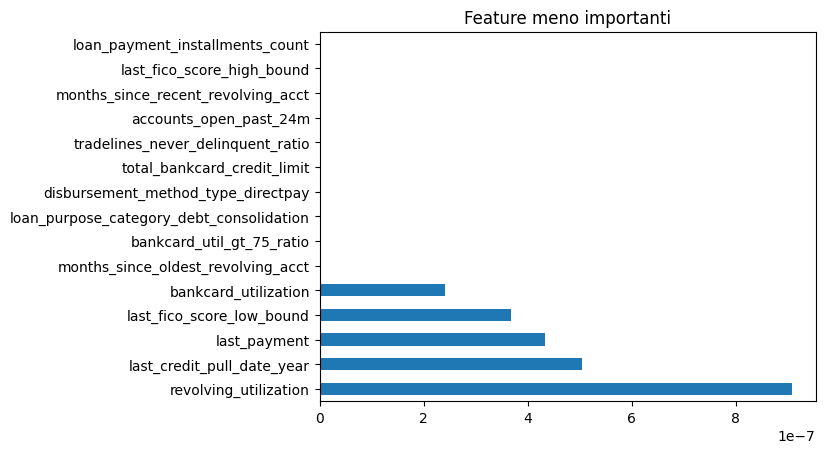

In [28]:
feature_importances = best_model.feature_importances_

fi_top = pd.Series(
    feature_importances,
    index=X_train.columns
).sort_values(ascending=False)

fi_worse = pd.Series(
    feature_importances,
    index=X_train.columns
).sort_values(ascending=True)

fi_top.head(15).plot(kind="barh", title="Feature più importanti")
plt.gca().invert_yaxis()
plt.show()

fi_worse.head(15).plot(kind="barh", title="Feature meno importanti")
plt.gca().invert_yaxis()
plt.show()


## 2. TabTransformer

In [7]:
train = pd.read_csv(TRAIN_SET_PATH_ONLY_LABEL)
val = pd.read_csv(VAL_SET_PATH_ONLY_LABEL)
test = pd.read_csv(TEST_SET_PATH_ONLY_LABEL)

X_train = train.drop(columns=['grade'])
y_train = train["grade"]

X_val = val.drop(columns=['grade'])
y_val = val["grade"]

X_test = test.drop(columns=['grade'])
y_test = test["grade"]

print(f"TRAIN:\nX: {X_train.shape}\ny: {y_train.shape}")
print(f"VAL:\nX: {X_val.shape}\ny: {y_val.shape}")
print(f"TEST:\nX: {X_test.shape}\ny: {y_test.shape}")

TRAIN:
X: (33747, 35)
y: (33747,)
VAL:
X: (14830, 35)
y: (14830,)
TEST:
X: (14831, 35)
y: (14831,)


### Iperparametri

In [ ]:
param_list = {
    'dim': [32], 
    'depth': [6], 
    'heads': [8],
    'attn_dropout': [0.1],
    'ff_dropout': [0.1]
}

### Data config

In [11]:
assets = load_assets(ASSETS_PATH_ONLY_LABEL)

numeric_features = assets['numeric_features']
categorical_features = assets['categorical_features']

data_config = DataConfig(
    target=['grade'],
    continuous_cols=numeric_features,
    categorical_cols=categorical_features,
)

### Addestramento

In [ ]:
def sample_params_transformer(params_list):
    return {k: random.choice(v) for k, v in params_list.items()}

best_score = -1
best_params = None
N_TRIALS = 1

for trial in range(N_TRIALS):
    params = sample_params_transformer(param_list)
    print(f"\nTrial {trial+1}/{N_TRIALS} | Params: {params}")

    model_config = TabTransformerConfig(
        task="classification",
        input_embed_dim=params['dim'],
        num_attn_blocks=params['depth'],
        num_heads=params['heads'],
        attn_dropout=params['attn_dropout'],
        ff_dropout=params['ff_dropout']
    )

    trainer_config = TrainerConfig(
        batch_size=1024,
        max_epochs=200,
        early_stopping_patience=10,
        checkpoints=None,
        accelerator="cpu",   # forza CPU
        devices=1
    )

    tabular_model = TabularModel(
        data_config=data_config,
        model_config=model_config,
        optimizer_config=OptimizerConfig(),
        trainer_config=trainer_config
    )

    history = tabular_model.fit(train=train, validation=val)

    result = tabular_model.evaluate(val)
    score = result[0]['test_accuracy']
    print(f"Val score: {score}")

    if score > best_score:
        best_score = score
        best_params = params
        best_model = deepcopy(tabular_model)

# Salvataggio finale
tabular_model.model.to("cpu")
best_model.save_model(f"../Test_module/models/tabtransformer")
print(f"\nRicerca completata. Miglior Score: {best_score} con Params: {best_params}")

INFO:pytorch_tabular.tabular_model:Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_tabular.tabular_model:Preparing the DataLoaders
INFO:pytorch_tabular.tabular_datamodule:Setting up the datamodule for classification task
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_encoded[col].fillna(self._imputed, inplace=True)
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:3


Trial 1/1 | Params: {'dim': 32, 'depth': 6, 'heads': 8, 'attn_dropout': 0.1, 'ff_dropout': 0.1}


INFO:pytorch_tabular.tabular_model:Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_tabular.tabular_model:Training Started


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                   ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ TabTransformerBackbone │  271 K │ train │
│ 1 │ _embedding_layer │ Embedding2dLayer       │    936 │ train │
│ 2 │ _head            │ LinearHead             │  1.3 K │ train │
│ 3 │ loss             │ CrossEntropyLoss       │      0 │ train │
└───┴──────────────────┴────────────────────────┴────────┴───────┘

Trainable params: 273 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 273 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 129                                                                                         
Modules in eval mode: 0

...

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_encoded[col].fillna(self._imputed, inplace=True)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8209035992622375     │
│         test_loss         │    0.4892421364784241     │
│        test_loss_0        │    0.4892421364784241     │
└───────────────────────────┴───────────────────────────┘

Val score: 0.8209035992622375



Ricerca completata. Miglior Score: 0.8209035992622375 con Params: {'dim': 32, 'depth': 6, 'heads': 8, 'attn_dropout': 0.1, 'ff_dropout': 0.1}


### Test

In [ ]:
tabular_model = TabularModel.load_model(f"../Test_module/models/tabtransformer")

pred_df = tabular_model.predict(X_test)
y_pred = pred_df["grade_prediction"]

print(f"Test accuracy finale: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

INFO:pytorch_tabular.tabular_model:Experiment Tracking is turned off
INFO:pytorch_tabular.tabular_model:Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/categorical_encoders.py:71: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

Test accuracy finale: 0.8226687344076596
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      2647
           1       0.89      0.85      0.87      3789
           2       0.86      0.82      0.84      3689
           3       0.75      0.82      0.78      2156
           4       0.68      0.64      0.66      1203
           5       0.54      0.51      0.53       711
           6       0.68      0.84      0.75       636

    accuracy                           0.82     14831
   macro avg       0.76      0.78      0.77     14831
weighted avg       0.82      0.82      0.82     14831



### Visualizzazione

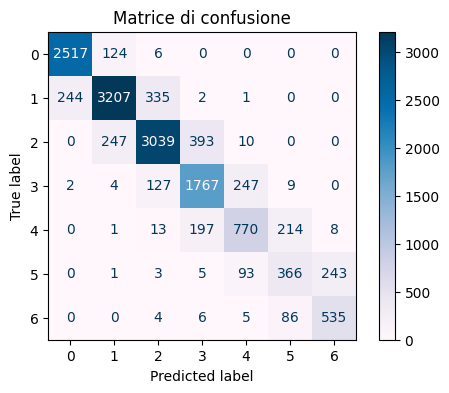

In [18]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(7))
disp.plot(cmap='PuBu', ax=ax)
plt.title("Matrice di confusione")
plt.show()